Latent FID DataFrame:
 epoch  FID_latent_mean
 10000        73.252503
 15000        72.822257
 20000        61.487920
 25000        76.550175
 30000        88.385613
 35000        99.127652
 40000       110.594570
 45000       107.964733
 50000       118.406511
 55000       134.376157
 60000       115.842766

Reference FID DataFrame:
 epoch  FID_reference_mean
 10000           89.840464
 15000          100.961053
 20000          171.447058
 25000          168.903009
 30000          176.572434
 35000          115.710952
 40000          122.623995
 45000          124.360974
 50000          109.019744
 55000           99.420325
 60000          115.912573


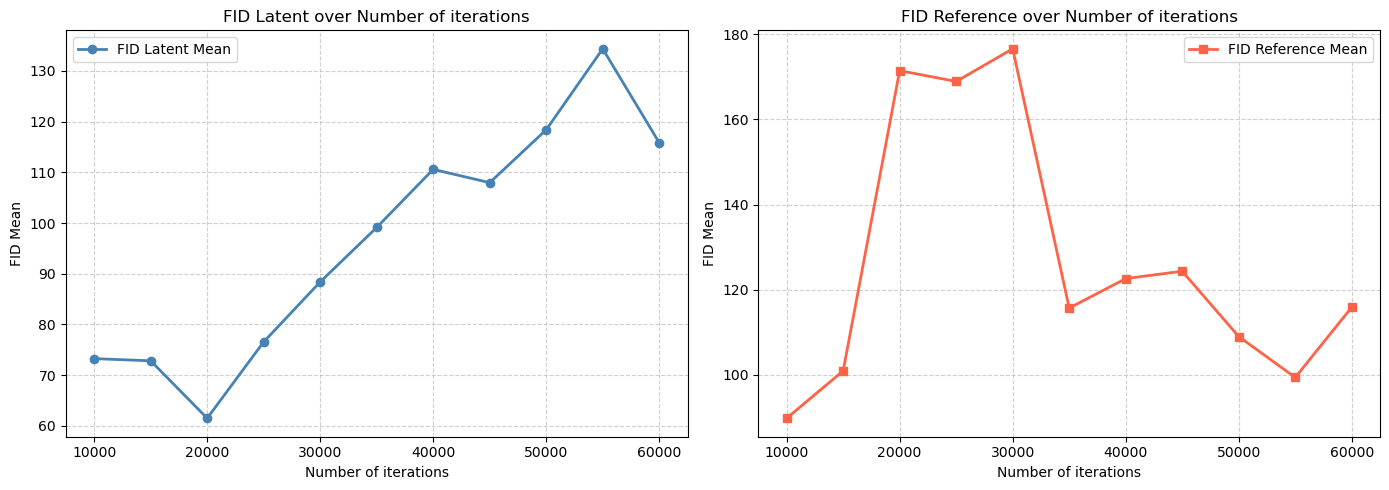


Plot saved to fid_scores.png


In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "/scratch-shared/TSAJOTO001/OCTA/stargan-v2/expr/eval/testB2testA"

latent_data = {}  # epoch -> FID_latent/mean
ref_data    = {}  # epoch -> FID_reference/mean

for epoch in range(10000, 65000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"FID_{epoch_str}_latent.json"
    ref_filename    = f"FID_{epoch_str}_reference.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        fid_value = data.get("FID_latent/mean")
        if fid_value is not None:
            latent_data[epoch] = fid_value
    else:
        print(f"Not found: {latent_filename}")

    # --- Reference ---
    ref_filepath = os.path.join(folder_path, ref_filename)
    if os.path.isfile(ref_filepath):
        with open(ref_filepath, "r") as f:
            data = json.load(f)
        fid_value = data.get("FID_reference/mean")
        if fid_value is not None:
            ref_data[epoch] = fid_value
    else:
        print(f"Not found: {ref_filename}")

# Build DataFrames
df_latent = pd.DataFrame(sorted(latent_data.items()), columns=["epoch", "FID_latent_mean"])
df_ref    = pd.DataFrame(sorted(ref_data.items()),    columns=["epoch", "FID_reference_mean"])

print("Latent FID DataFrame:")
print(df_latent.to_string(index=False))
print("\nReference FID DataFrame:")
print(df_ref.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent.empty:
    axes[0].plot(df_latent["epoch"], df_latent["FID_latent_mean"],
                 marker="o", linewidth=2, color="steelblue", label="FID Latent Mean")
    axes[0].set_title("FID Latent over Number of iterations")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("FID Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("FID Latent over Number of iterations")

if not df_ref.empty:
    axes[1].plot(df_ref["epoch"], df_ref["FID_reference_mean"],
                 marker="s", linewidth=2, color="tomato", label="FID Reference Mean")
    axes[1].set_title("FID Reference over Number of iterations")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("FID Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("FID Reference over Number of iterations")

plt.tight_layout()
plt.savefig("fid_scores.png", dpi=150)
plt.show()
print("\nPlot saved to fid_scores.png")

Latent LPIPS DataFrame:
 epoch  LPIPS_latent_mean
 10000           0.142721
 15000           0.136567
 20000           0.115701
 25000           0.112996
 30000           0.097156
 35000           0.080799
 40000           0.064012
 45000           0.057523
 50000           0.052176

Reference LPIPS DataFrame:
 epoch  LPIPS_reference_mean
 10000              0.132667
 15000              0.134196
 20000              0.121013
 25000              0.114510
 30000              0.098036
 35000              0.080555
 40000              0.061598
 45000              0.081233
 50000              0.068677


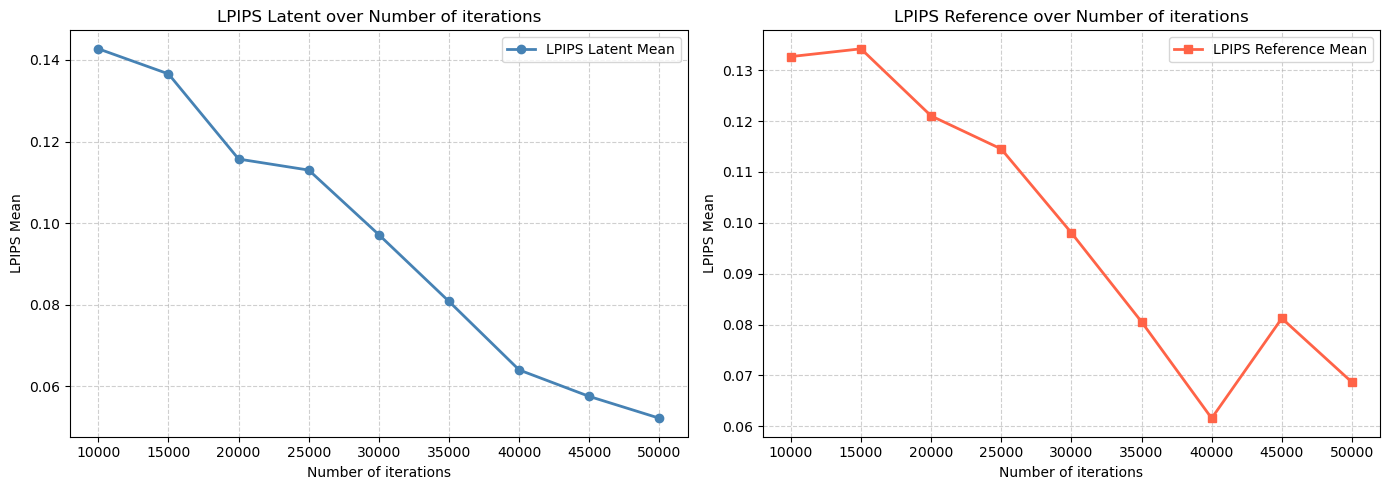


Plot saved to LPIPS_scores.png


In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_data = {}  # epoch -> FID_latent/mean
ref_data    = {}  # epoch -> FID_reference/mean

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"LPIPS_{epoch_str}_latent.json"
    ref_filename    = f"LPIPS_{epoch_str}_reference.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        LPIPS_value = data.get("LPIPS_latent/mean")
        if LPIPS_value is not None:
            latent_data[epoch] = LPIPS_value
    else:
        print(f"Not found: {latent_filename}")

    # --- Reference ---
    ref_filepath = os.path.join(folder_path, ref_filename)
    if os.path.isfile(ref_filepath):
        with open(ref_filepath, "r") as f:
            data = json.load(f)
        LPIPS_value = data.get("LPIPS_reference/mean")
        if LPIPS_value is not None:
            ref_data[epoch] = LPIPS_value
    else:
        print(f"Not found: {ref_filename}")

# Build DataFrames
df_latent = pd.DataFrame(sorted(latent_data.items()), columns=["epoch", "LPIPS_latent_mean"])
df_ref    = pd.DataFrame(sorted(ref_data.items()),    columns=["epoch", "LPIPS_reference_mean"])

print("Latent LPIPS DataFrame:")
print(df_latent.to_string(index=False))
print("\nReference LPIPS DataFrame:")
print(df_ref.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent.empty:
    axes[0].plot(df_latent["epoch"], df_latent["LPIPS_latent_mean"],
                 marker="o", linewidth=2, color="steelblue", label="LPIPS Latent Mean")
    axes[0].set_title("LPIPS Latent over Number of iterations")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("LPIPS Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("LPIPS Latent over Number of iterations")

if not df_ref.empty:
    axes[1].plot(df_ref["epoch"], df_ref["LPIPS_reference_mean"],
                 marker="s", linewidth=2, color="tomato", label="LPIPS Reference Mean")
    axes[1].set_title("LPIPS Reference over Number of iterations")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("LPIPS Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("LPIPS Reference over Number of iterations")

plt.tight_layout()
plt.savefig("LPIPS_scores.png", dpi=150)
plt.show()
print("\nPlot saved to LPIPS_scores.png")

LPIPS A2B DataFrame:
 epoch  LPIPS_latent/A2B
 10000          0.131431
 15000          0.123990
 20000          0.107707
 25000          0.097853
 30000          0.085873
 35000          0.087232
 40000          0.081804
 45000          0.089322
 50000          0.086122

LPIPS A2C DataFrame:
 epoch  LPIPS_latent/A2C
 10000          0.014393
 15000          0.009695
 20000          0.006482
 25000          0.006314
 30000          0.012912
 35000          0.018338
 40000          0.020045
 45000          0.019776
 50000          0.021311


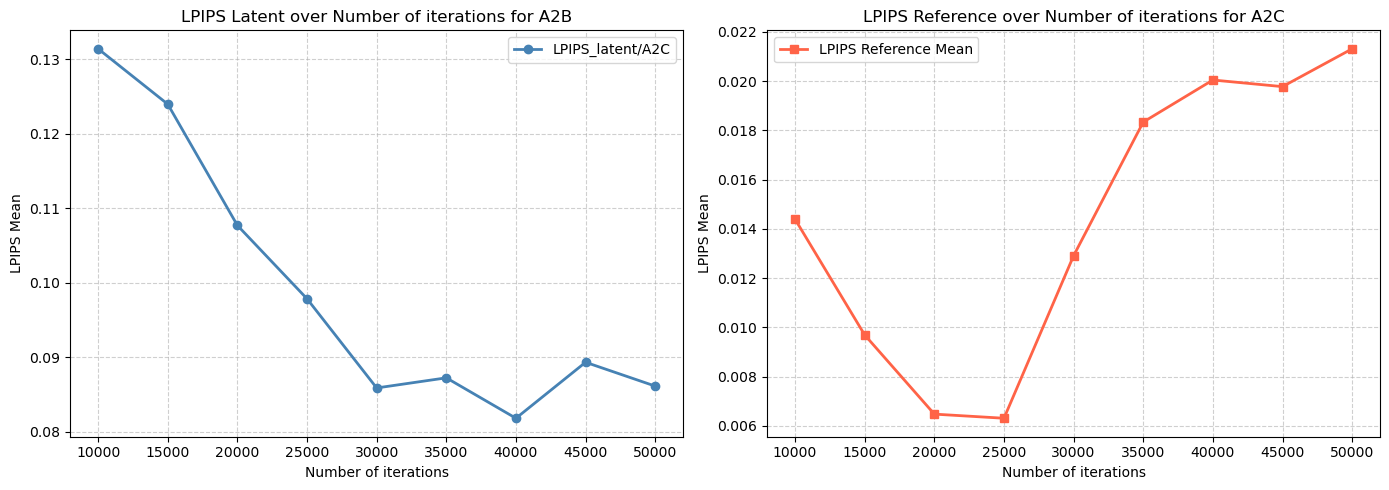


Plot saved to A_LPIPS_scores.png


In [8]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_A2B = {}  # epoch -> LPIPS_latent/mean
latent_A2C = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"LPIPS_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        LPIPS_A2B = data.get("LPIPS_latent/A2B")
        LPIPS_A2C = data.get("LPIPS_latent/A2C")
        if LPIPS_A2C is not None:
            latent_A2C[epoch] = LPIPS_A2C
        if LPIPS_A2B is not None:
            latent_A2B[epoch] = LPIPS_A2B
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_A2C = pd.DataFrame(sorted(latent_A2C.items()), columns=["epoch", "LPIPS_latent/A2C"])
df_latent_A2B = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "LPIPS_latent/A2B"])

print("LPIPS A2B DataFrame:")
print(df_latent_A2B.to_string(index=False))
print("\nLPIPS A2C DataFrame:")
print(df_latent_A2C.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_A2B.empty:
    axes[0].plot(df_latent_A2B["epoch"], df_latent_A2B["LPIPS_latent/A2B"],
                 marker="o", linewidth=2, color="steelblue", label="LPIPS_latent/A2C")
    axes[0].set_title("LPIPS Latent over Number of iterations for A2B")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("LPIPS Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("LPIPS Latent over Number of iterations")

if not df_latent_A2C.empty:
    axes[1].plot(df_latent_A2C["epoch"], df_latent_A2C["LPIPS_latent/A2C"],
                 marker="s", linewidth=2, color="tomato", label="LPIPS Reference Mean")
    axes[1].set_title("LPIPS Reference over Number of iterations for A2C")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("LPIPS Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("LPIPS Reference over Number of iterations")

plt.tight_layout()
plt.savefig("A_LPIPS_scores.png", dpi=150)
plt.show()
print("\nPlot saved to A_LPIPS_scores.png")

LPIPS B2A DataFrame:
 epoch  LPIPS_latent/B2A
 10000          0.182568
 15000          0.182373
 20000          0.182035
 25000          0.148179
 30000          0.141119
 35000          0.100017
 40000          0.058215
 45000          0.044844
 50000          0.039087

LPIPS B2C DataFrame:
 epoch  LPIPS_latent/B2C
 10000          0.131431
 15000          0.123990
 20000          0.107707
 25000          0.097853
 30000          0.085873
 35000          0.087232
 40000          0.081804
 45000          0.089322
 50000          0.086122


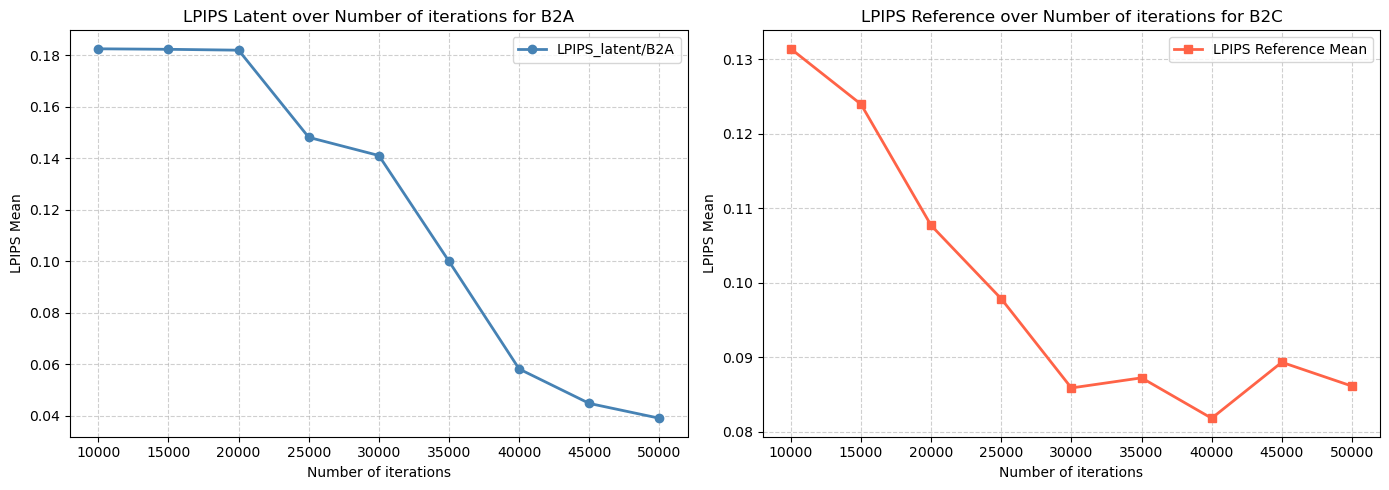


Plot saved to B_LPIPS_scores.png


In [9]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_B2A = {}  # epoch -> LPIPS_latent/mean
latent_B2C = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"LPIPS_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        LPIPS_B2A = data.get("LPIPS_latent/B2A")
        LPIPS_B2C = data.get("LPIPS_latent/B2C")
        if LPIPS_B2A is not None:
            latent_B2A[epoch] = LPIPS_B2A
        if LPIPS_B2C is not None:
            latent_B2C[epoch] = LPIPS_B2C
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_B2A = pd.DataFrame(sorted(latent_B2A.items()), columns=["epoch", "LPIPS_latent/B2A"])
df_latent_B2C = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "LPIPS_latent/B2C"])

print("LPIPS B2A DataFrame:")
print(df_latent_B2A.to_string(index=False))
print("\nLPIPS B2C DataFrame:")
print(df_latent_B2C.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_B2A.empty:
    axes[0].plot(df_latent_B2A["epoch"], df_latent_B2A["LPIPS_latent/B2A"],
                 marker="o", linewidth=2, color="steelblue", label="LPIPS_latent/B2A")
    axes[0].set_title("LPIPS Latent over Number of iterations for B2A")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("LPIPS Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("LPIPS Latent over Number of iterations")

if not df_latent_B2C.empty:
    axes[1].plot(df_latent_B2C["epoch"], df_latent_B2C["LPIPS_latent/B2C"],
                 marker="s", linewidth=2, color="tomato", label="LPIPS Reference Mean")
    axes[1].set_title("LPIPS Reference over Number of iterations for B2C")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("LPIPS Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("LPIPS Reference over Number of iterations for B2C")

plt.tight_layout()
plt.savefig("B_LPIPS_scores.png", dpi=150)
plt.show()
print("\nPlot saved to B_LPIPS_scores.png")

LPIPS C2A DataFrame:
 epoch  LPIPS_latent/C2A
 10000          0.195806
 15000          0.189834
 20000          0.219510
 25000          0.190866
 30000          0.146891
 35000          0.105142
 40000          0.073365
 45000          0.059872
 50000          0.047885

LPIPS C2B DataFrame:
 epoch  LPIPS_latent/C2B
 10000          0.131431
 15000          0.123990
 20000          0.107707
 25000          0.097853
 30000          0.085873
 35000          0.087232
 40000          0.081804
 45000          0.089322
 50000          0.086122


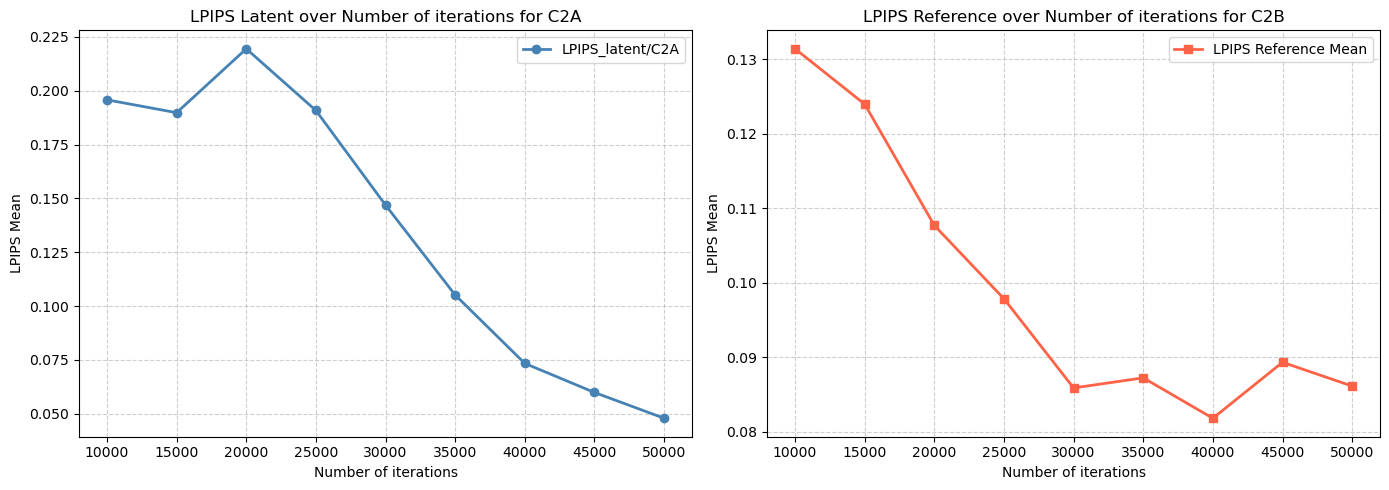


Plot saved to C_LPIPS_scores.png


In [10]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_C2A = {}  # epoch -> LPIPS_latent/mean
latent_C2B = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"LPIPS_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        LPIPS_C2A = data.get("LPIPS_latent/C2A")
        LPIPS_C2B = data.get("LPIPS_latent/C2B")
        if LPIPS_C2A is not None:
            latent_C2A[epoch] = LPIPS_C2A
        if LPIPS_C2B is not None:
            latent_C2B[epoch] = LPIPS_C2B
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_C2A = pd.DataFrame(sorted(latent_C2A.items()), columns=["epoch", "LPIPS_latent/C2A"])
df_latent_C2B = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "LPIPS_latent/C2B"])

print("LPIPS C2A DataFrame:")
print(df_latent_C2A.to_string(index=False))
print("\nLPIPS C2B DataFrame:")
print(df_latent_C2B.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_C2A.empty:
    axes[0].plot(df_latent_C2A["epoch"], df_latent_C2A["LPIPS_latent/C2A"],
                 marker="o", linewidth=2, color="steelblue", label="LPIPS_latent/C2A")
    axes[0].set_title("LPIPS Latent over Number of iterations for C2A")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("LPIPS Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("LPIPS Latent over Number of iterations")

if not df_latent_C2B.empty:
    axes[1].plot(df_latent_C2B["epoch"], df_latent_C2B["LPIPS_latent/C2B"],
                 marker="s", linewidth=2, color="tomato", label="LPIPS Reference Mean")
    axes[1].set_title("LPIPS Reference over Number of iterations for C2B")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("LPIPS Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("LPIPS Reference over Number of iterations for C2B")

plt.tight_layout()
plt.savefig("C_LPIPS_scores.png", dpi=150)
plt.show()
print("\nPlot saved to C_LPIPS_scores.png")

In [1]:
epochs = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
cf = {
    'epoch': epochs,
    'CF_FID': [329.876, 294.918, 257.823, 225.312, 241.000, 202.446, 177.982, 174.157, 175.227, 172.229, 165.741, 160.886]
}
ffa = {
    'epoch': epochs,
    'FFA_FID': [411.836, 440.664, 254.381, 331.530, 273.050, 264.389, 218.659, 241.025, 227.158, 205.548, 219.918, 214.647]
}
octa = {
    'epoch': epochs,
    'OCTA_FID': [475.576, 397.672, 389.254, 419.153, 430.106, 390.388, 417.487, 411.335, 435.511, 401.779, 411.210, 410.060]
}

In [3]:
import pandas as pd

cf_fid = pd.DataFrame(cf)
ffa_fid = pd.DataFrame(ffa)
octa_fid = pd.DataFrame(octa)

In [4]:
si = pd.merge(cf_fid, ffa_fid, on='epoch')
si.head()

,epoch,CF_FID,FFA_FID
0,5,329.876,411.836
1,10,294.918,440.664
2,15,257.823,254.381
3,20,225.312,331.530
4,25,241.000,273.050


In [5]:
singlegan = pd.merge(si, octa_fid, on='epoch')
singlegan.head()

,epoch,CF_FID,FFA_FID,OCTA_FID
0,5,329.876,411.836,475.576
1,10,294.918,440.664,397.672
2,15,257.823,254.381,389.254
3,20,225.312,331.530,419.153
4,25,241.000,273.050,430.106


In [6]:
sel = ['CF_FID', 'FFA_FID', 'OCTA_FID']
singlegan['fid_mean'] = singlegan[sel].mean(axis=1)

In [7]:
singlegan.head()

,epoch,CF_FID,FFA_FID,OCTA_FID,fid_mean
0,5,329.876,411.836,475.576,405.762667
1,10,294.918,440.664,397.672,377.751333
2,15,257.823,254.381,389.254,300.486000
3,20,225.312,331.530,419.153,325.331667
4,25,241.000,273.050,430.106,314.718667


In [8]:
singlegan

,epoch,CF_FID,FFA_FID,OCTA_FID,fid_mean
0,5,329.876,411.836,475.576,405.762667
1,10,294.918,440.664,397.672,377.751333
2,15,257.823,254.381,389.254,300.486000
3,20,225.312,331.530,419.153,325.331667
4,25,241.000,273.050,430.106,314.718667
5,30,202.446,264.389,390.388,285.741000
6,35,177.982,218.659,417.487,271.376000
7,40,174.157,241.025,411.335,275.505667
8,45,175.227,227.158,435.511,279.298667
9,50,172.229,205.548,401.779,259.852000


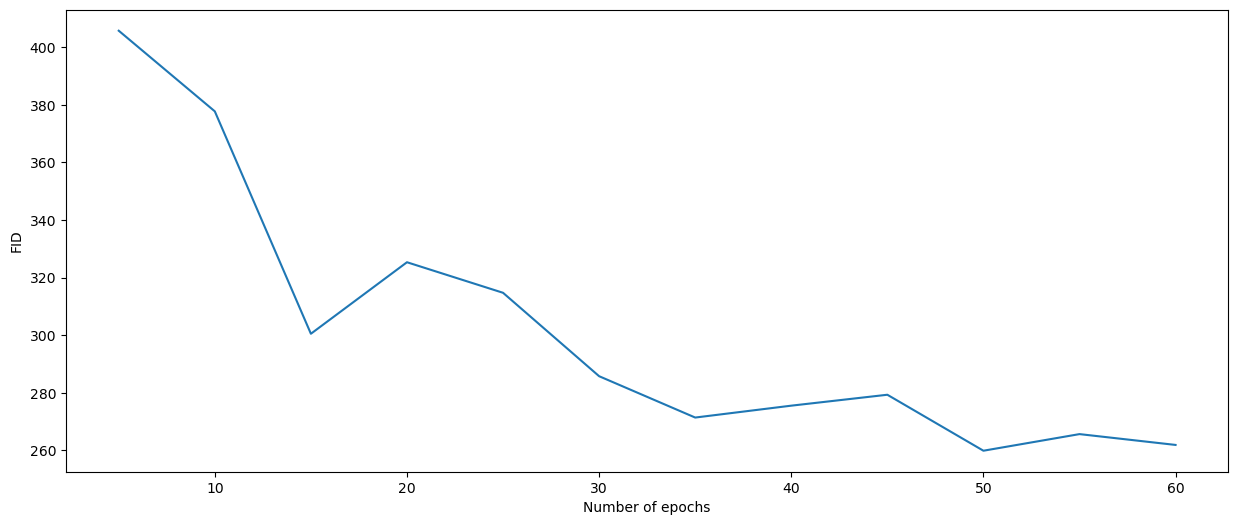

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.xlabel('Number of epochs')
plt.ylabel('FID')
# plt.locator_params(axis='x', nbins=80)
plt.plot(singlegan['epoch'], singlegan['fid_mean'])
plt.savefig("singlegan_fid.png", dpi=150)
plt.show()

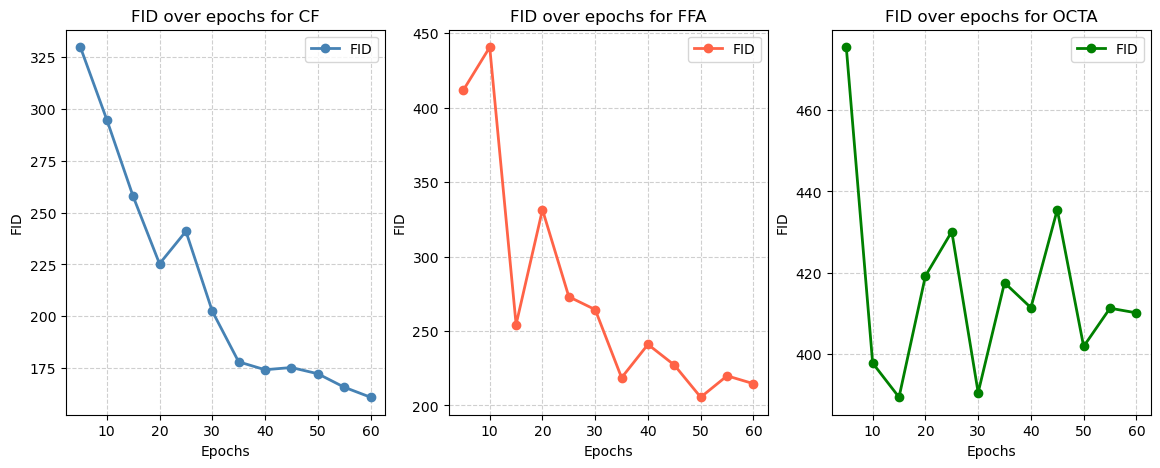

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].plot(cf["epoch"], cf["FID"],
                 marker="o", linewidth=2, color="steelblue", label="FID")
axes[0].set_title("FID over epochs for CF")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("FID")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(ffa["epoch"], ffa["FID"],
                 marker="o", linewidth=2, color="tomato", label="FID")
axes[1].set_title("FID over epochs for FFA")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("FID")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

axes[2].plot(octa["epoch"], octa["FID"],
                 marker="o", linewidth=2, color="green", label="FID")
axes[2].set_title("FID over epochs for OCTA")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("FID")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.6)
plt.savefig("singlegan_fid_scores.png", dpi=150)

FID A2B DataFrame:
 epoch  FID_latent/A2B
 10000       46.299075
 15000       47.544134
 20000       48.469644
 25000       45.687002
 30000       55.262881
 35000       52.737340
 40000       53.613325
 45000       51.248481
 50000       50.072733

FID A2C DataFrame:
 epoch  FID_latent/A2C
 10000       47.331505
 15000       40.297618
 20000       34.583226
 25000       30.388942
 30000       27.807600
 35000       25.585727
 40000       24.413018
 45000       24.522295
 50000       23.758973


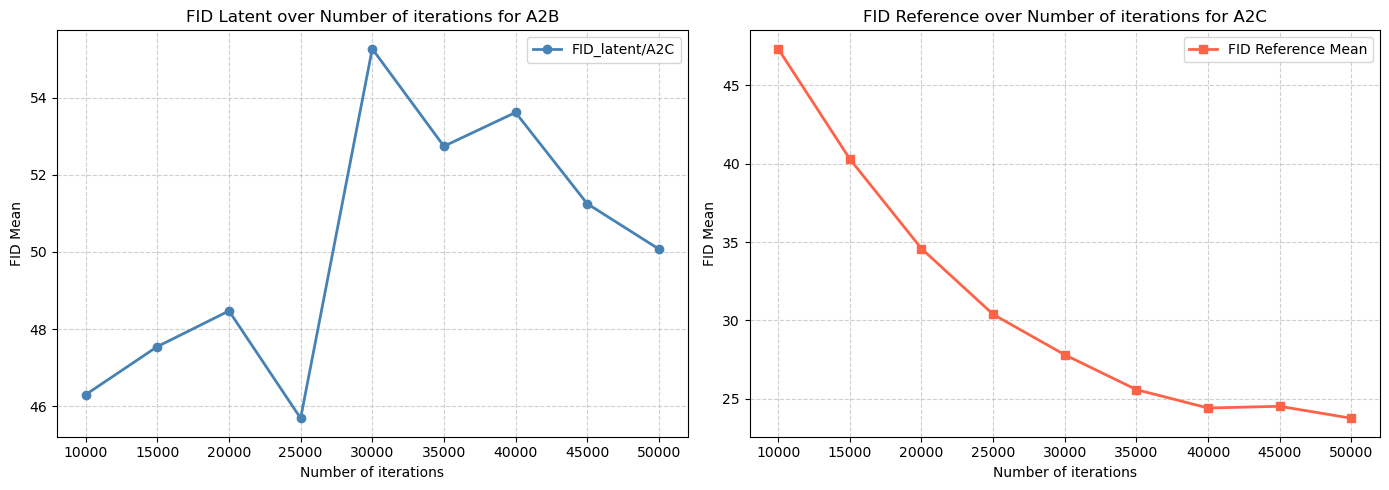


Plot saved to A_fid_scores.png


In [14]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_A2B = {}  # epoch -> FID_latent/mean
latent_A2C = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"FID_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        fid_A2B = data.get("FID_latent/A2B")
        fid_A2C = data.get("FID_latent/A2C")
        if fid_A2C is not None:
            latent_A2C[epoch] = fid_A2C
        if fid_A2B is not None:
            latent_A2B[epoch] = fid_A2B
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_A2C = pd.DataFrame(sorted(latent_A2C.items()), columns=["epoch", "FID_latent/A2C"])
df_latent_A2B = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "FID_latent/A2B"])

print("FID A2B DataFrame:")
print(df_latent_A2B.to_string(index=False))
print("\nFID A2C DataFrame:")
print(df_latent_A2C.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_A2B.empty:
    axes[0].plot(df_latent_A2B["epoch"], df_latent_A2B["FID_latent/A2B"],
                 marker="o", linewidth=2, color="steelblue", label="FID_latent/A2C")
    axes[0].set_title("FID Latent over Number of iterations for A2B")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("FID Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("FID Latent over Number of iterations")

if not df_latent_A2C.empty:
    axes[1].plot(df_latent_A2C["epoch"], df_latent_A2C["FID_latent/A2C"],
                 marker="s", linewidth=2, color="tomato", label="FID Reference Mean")
    axes[1].set_title("FID Reference over Number of iterations for A2C")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("FID Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("FID Reference over Number of iterations")

plt.tight_layout()
plt.savefig("A_fid_scores.png", dpi=150)
plt.show()
print("\nPlot saved to A_fid_scores.png")

FID B2A DataFrame:
 epoch  FID_latent/B2A
 10000       47.423313
 15000       46.889830
 20000       55.669527
 25000       59.024538
 30000       64.824553
 35000       73.328780
 40000       85.100517
 45000       75.874797
 50000       72.434664

FID B2C DataFrame:
 epoch  FID_latent/B2C
 10000       46.299075
 15000       47.544134
 20000       48.469644
 25000       45.687002
 30000       55.262881
 35000       52.737340
 40000       53.613325
 45000       51.248481
 50000       50.072733


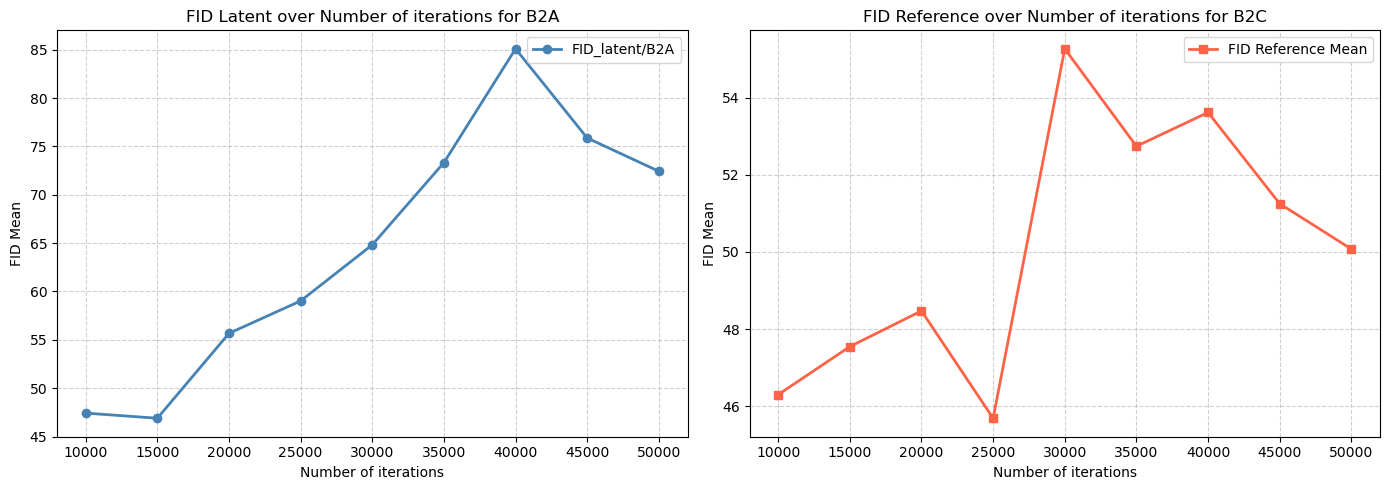


Plot saved to B_fid_scores.png


In [17]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_B2A = {}  # epoch -> FID_latent/mean
latent_B2C = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"FID_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        fid_B2A = data.get("FID_latent/B2A")
        fid_B2C = data.get("FID_latent/B2C")
        if fid_B2A is not None:
            latent_B2A[epoch] = fid_B2A
        if fid_B2C is not None:
            latent_B2C[epoch] = fid_B2C
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_B2A = pd.DataFrame(sorted(latent_B2A.items()), columns=["epoch", "FID_latent/B2A"])
df_latent_B2C = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "FID_latent/B2C"])

print("FID B2A DataFrame:")
print(df_latent_B2A.to_string(index=False))
print("\nFID B2C DataFrame:")
print(df_latent_B2C.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_B2A.empty:
    axes[0].plot(df_latent_B2A["epoch"], df_latent_B2A["FID_latent/B2A"],
                 marker="o", linewidth=2, color="steelblue", label="FID_latent/B2A")
    axes[0].set_title("FID Latent over Number of iterations for B2A")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("FID Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("FID Latent over Number of iterations")

if not df_latent_B2C.empty:
    axes[1].plot(df_latent_B2C["epoch"], df_latent_B2C["FID_latent/B2C"],
                 marker="s", linewidth=2, color="tomato", label="FID Reference Mean")
    axes[1].set_title("FID Reference over Number of iterations for B2C")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("FID Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("FID Reference over Number of iterations for B2C")

plt.tight_layout()
plt.savefig("B_fid_scores.png", dpi=150)
plt.show()
print("\nPlot saved to B_fid_scores.png")

FID C2A DataFrame:
 epoch  FID_latent/C2A
 10000       97.906097
 15000      103.091570
 20000      112.653883
 25000      120.262877
 30000      150.304080
 35000      206.578146
 40000      237.625531
 45000      251.187328
 50000      302.910320

FID C2B DataFrame:
 epoch  FID_latent/C2B
 10000       46.299075
 15000       47.544134
 20000       48.469644
 25000       45.687002
 30000       55.262881
 35000       52.737340
 40000       53.613325
 45000       51.248481
 50000       50.072733


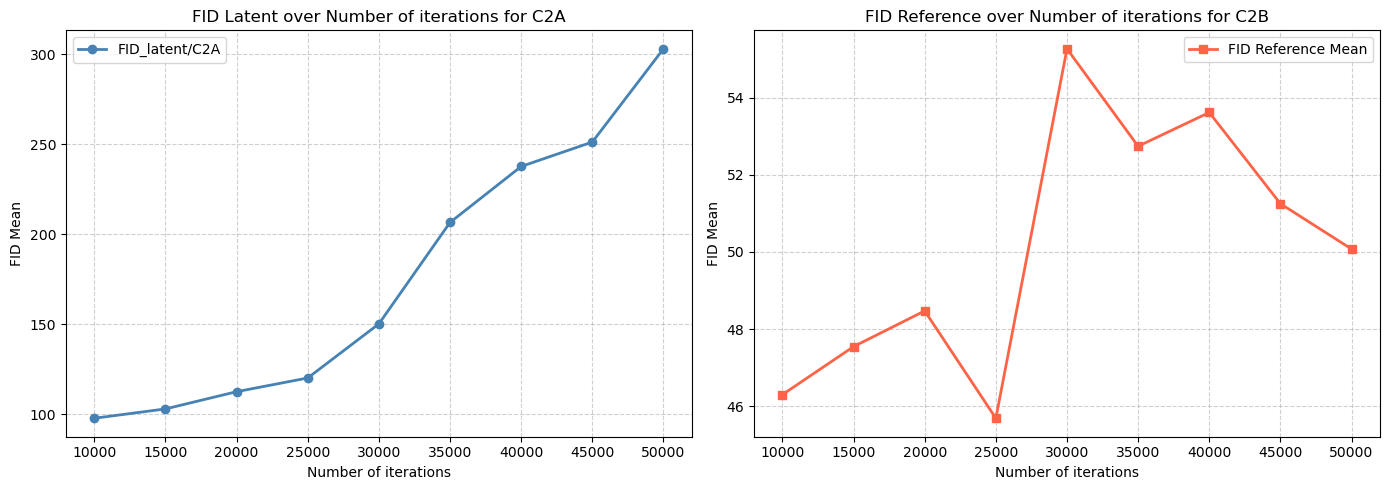


Plot saved to C_fid_scores.png


In [18]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "OCTA/stargan-v2/expr/eval/testB2testA"

latent_C2A = {}  # epoch -> FID_latent/mean
latent_C2B = {}

for epoch in range(10000, 55000, 5000):
    epoch_str = f"{epoch:05d}"  # zero-padded to 5 digits, e.g. 05000, 10000

    latent_filename = f"FID_{epoch_str}_latent.json"

    # --- Latent ---
    latent_filepath = os.path.join(folder_path, latent_filename)
    if os.path.isfile(latent_filepath):
        with open(latent_filepath, "r") as f:
            data = json.load(f)
        fid_C2A = data.get("FID_latent/C2A")
        fid_C2B = data.get("FID_latent/C2B")
        if fid_C2A is not None:
            latent_C2A[epoch] = fid_C2A
        if fid_C2B is not None:
            latent_C2B[epoch] = fid_C2B
    else:
        print(f"Not found: {latent_filename}")

# Build DataFrames
df_latent_C2A = pd.DataFrame(sorted(latent_C2A.items()), columns=["epoch", "FID_latent/C2A"])
df_latent_C2B = pd.DataFrame(sorted(latent_A2B.items()), columns=["epoch", "FID_latent/C2B"])

print("FID C2A DataFrame:")
print(df_latent_C2A.to_string(index=False))
print("\nFID C2B DataFrame:")
print(df_latent_C2B.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if not df_latent_C2A.empty:
    axes[0].plot(df_latent_C2A["epoch"], df_latent_C2A["FID_latent/C2A"],
                 marker="o", linewidth=2, color="steelblue", label="FID_latent/C2A")
    axes[0].set_title("FID Latent over Number of iterations for C2A")
    axes[0].set_xlabel("Number of iterations")
    axes[0].set_ylabel("FID Mean")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No latent data found", ha="center", va="center")
    axes[0].set_title("FID Latent over Number of iterations")

if not df_latent_C2B.empty:
    axes[1].plot(df_latent_C2B["epoch"], df_latent_C2B["FID_latent/C2B"],
                 marker="s", linewidth=2, color="tomato", label="FID Reference Mean")
    axes[1].set_title("FID Reference over Number of iterations for C2B")
    axes[1].set_xlabel("Number of iterations")
    axes[1].set_ylabel("FID Mean")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)
else:
    axes[1].text(0.5, 0.5, "No reference data found", ha="center", va="center")
    axes[1].set_title("FID Reference over Number of iterations for C2B")

plt.tight_layout()
plt.savefig("C_fid_scores.png", dpi=150)
plt.show()
print("\nPlot saved to C_fid_scores.png")

In [2]:
import os
import cv2
import numpy as np
from PIL import Image
import logging
import sys

# Configure logging to print to the notebook cell (stdout)
logging.basicConfig(
    stream=sys.stdout,
    level=logging.INFO, # Change to logging.DEBUG for more detail
    format='%(levelname)s: %(message)s'
)

# -----------------------------
# 1. Split grid
# -----------------------------
def split_grid(image_path, rows, cols):
    img = Image.open(image_path)
    w, h = img.size
    
    cell_w = w // cols
    cell_h = h // rows
    
    grid = []
    
    for r in range(rows):
        row_imgs = []
        for c in range(cols):
            crop = img.crop((
                c * cell_w,
                r * cell_h,
                (c + 1) * cell_w,
                (r + 1) * cell_h
            ))
            row_imgs.append(crop)
        grid.append(row_imgs)
    
    return grid

# -----------------------------
# DL Classifier (REPLACES feature-based)
# -----------------------------
import torch
import torch.nn as nn
from torchvision import models, transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 3)

model.load_state_dict(torch.load("/scratch-shared/TSAJOTO001/DosGAN-PyTorch/dosgan/retinal_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

classes = ["cf", "ffa", "octa"]

def classify_dl(pil_img):
    img = transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    return classes[pred], confidence

def sort_images_to_base(grid, base_path, count):
    for r, row in enumerate(grid):
        src_label, conf = classify_dl(row[0])

        logging.info(f"Source: {src_label} ({conf:.2f})")

        for c in range(1, 4):
            if c == 1:
                tgt_label = 'cf'
            elif c == 2:
                tgt_label = 'ffa'
            elif c == 3:
                tgt_label = 'octa'

            logging.info(f"{src_label} -> {tgt_label}")

            folder = os.path.join(base_path, f"{src_label}2{tgt_label}")
            filename = f"{count}_row{r}_col{c}.png"

            row[c].save(os.path.join(folder, filename))

In [ ]:
import os
from pathlib import Path

base = '/scratch-shared/TSAJOTO001/DosGAN-PyTorch/dosgan/results_'

for i in range(5000, 205000, 5000):
    source = base + str(i)
    
    modalities = ["cf", "ffa", "octa"]
    
    for src in modalities:
        for tgt in modalities:
            folder = os.path.join(source, f"{src}2{tgt}")
            os.makedirs(folder, exist_ok=True)

    count = 0
    for img in Path(source).iterdir():
        count = count + 1
        if img.suffix == '.jpg':
            grid = split_grid(str(img), rows=6, cols=4)
            sort_images_to_base(grid, source, count)

INFO: Source: cf (1.00)
INFO: cf -> cf
INFO: cf -> ffa
INFO: cf -> octa
INFO: Source: cf (1.00)
INFO: cf -> cf
INFO: cf -> ffa
INFO: cf -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: cf (1.00)
INFO: cf -> cf
INFO: cf -> ffa
INFO: cf -> octa
INFO: Source: octa (1.00)
INFO: octa -> cf
INFO: octa -> ffa
INFO: octa -> octa
INFO: Source: octa (1.00)
INFO: octa -> cf
INFO: octa -> ffa
INFO: octa -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: cf (1.00)
INFO: cf -> cf
INFO: cf -> ffa
INFO: cf -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: cf (1.00)
INFO: cf -> cf
INFO: cf -> ffa
INFO: cf -> octa
INFO: Source: ffa (1.00)
INFO: ffa -> cf
INFO: ffa -> ffa
INFO: ffa -> octa
INFO: Source: ffa (1.00)

In [1]:
import pandas as pd
import numpy as np

dosgan = pd.read_csv('/scratch-shared/TSAJOTO001/fid_results.csv')

In [2]:
dosgan.head()

,iter,cf2ffa,cf2octa,ffa2cf,ffa2octa,octa2cf,octa2ffa
0,5000,300.160757,413.165856,227.924088,366.844523,238.880977,238.505059
1,10000,168.093913,NaN,198.026684,296.730695,230.513380,181.019582
2,15000,157.693705,253.267329,187.698401,251.020227,227.715264,162.179479
3,20000,183.063776,235.975535,186.139854,243.354604,214.394046,173.336851
4,25000,217.195972,NaN,183.248655,186.883092,197.056608,152.847862


In [3]:
sel = ['cf2ffa', 'cf2octa', 'ffa2cf', 'ffa2octa', 'octa2cf', 'octa2ffa']
dosgan['fid_mean'] = dosgan[sel].mean(axis=1)

In [4]:
dosgan

,iter,cf2ffa,cf2octa,ffa2cf,ffa2octa,octa2cf,octa2ffa,fid_mean
0,5000,300.160757,413.165856,227.924088,366.844523,238.880977,238.505059,297.580210
1,10000,168.093913,NaN,198.026684,296.730695,230.513380,181.019582,214.876851
2,15000,157.693705,253.267329,187.698401,251.020227,227.715264,162.179479,206.595734
3,20000,183.063776,235.975535,186.139854,243.354604,214.394046,173.336851,206.044111
4,25000,217.195972,NaN,183.248655,186.883092,197.056608,152.847862,187.446438
5,30000,295.087616,416.509687,165.825549,225.182681,191.264180,165.346926,243.202773
6,35000,271.695889,335.576360,159.144300,253.316550,177.418083,158.302359,225.908923
7,40000,281.090146,432.756582,167.977907,191.880058,186.030234,160.034281,236.628201
8,45000,273.462577,367.015636,151.649318,180.084668,166.336101,159.204777,216.292180
9,50000,293.759544,423.590248,173.140610,218.678432,178.389877,158.124391,240.947184


In [9]:
sel2 = ['cf2ffa', 'ffa2cf', 'ffa2octa', 'octa2ffa']
dosgan['fid_mean2'] = dosgan[sel2].mean(axis=1)

In [10]:
dosgan

,iter,cf2ffa,cf2octa,ffa2cf,ffa2octa,octa2cf,octa2ffa,fid_mean,fid_mean2
0,5000,300.160757,413.165856,227.924088,366.844523,238.880977,238.505059,297.580210,283.358607
1,10000,168.093913,NaN,198.026684,296.730695,230.513380,181.019582,214.876851,210.967718
2,15000,157.693705,253.267329,187.698401,251.020227,227.715264,162.179479,206.595734,189.647953
3,20000,183.063776,235.975535,186.139854,243.354604,214.394046,173.336851,206.044111,196.473771
4,25000,217.195972,NaN,183.248655,186.883092,197.056608,152.847862,187.446438,185.043895
5,30000,295.087616,416.509687,165.825549,225.182681,191.264180,165.346926,243.202773,212.860693
6,35000,271.695889,335.576360,159.144300,253.316550,177.418083,158.302359,225.908923,210.614775
7,40000,281.090146,432.756582,167.977907,191.880058,186.030234,160.034281,236.628201,200.245598
8,45000,273.462577,367.015636,151.649318,180.084668,166.336101,159.204777,216.292180,191.100335
9,50000,293.759544,423.590248,173.140610,218.678432,178.389877,158.124391,240.947184,210.925744


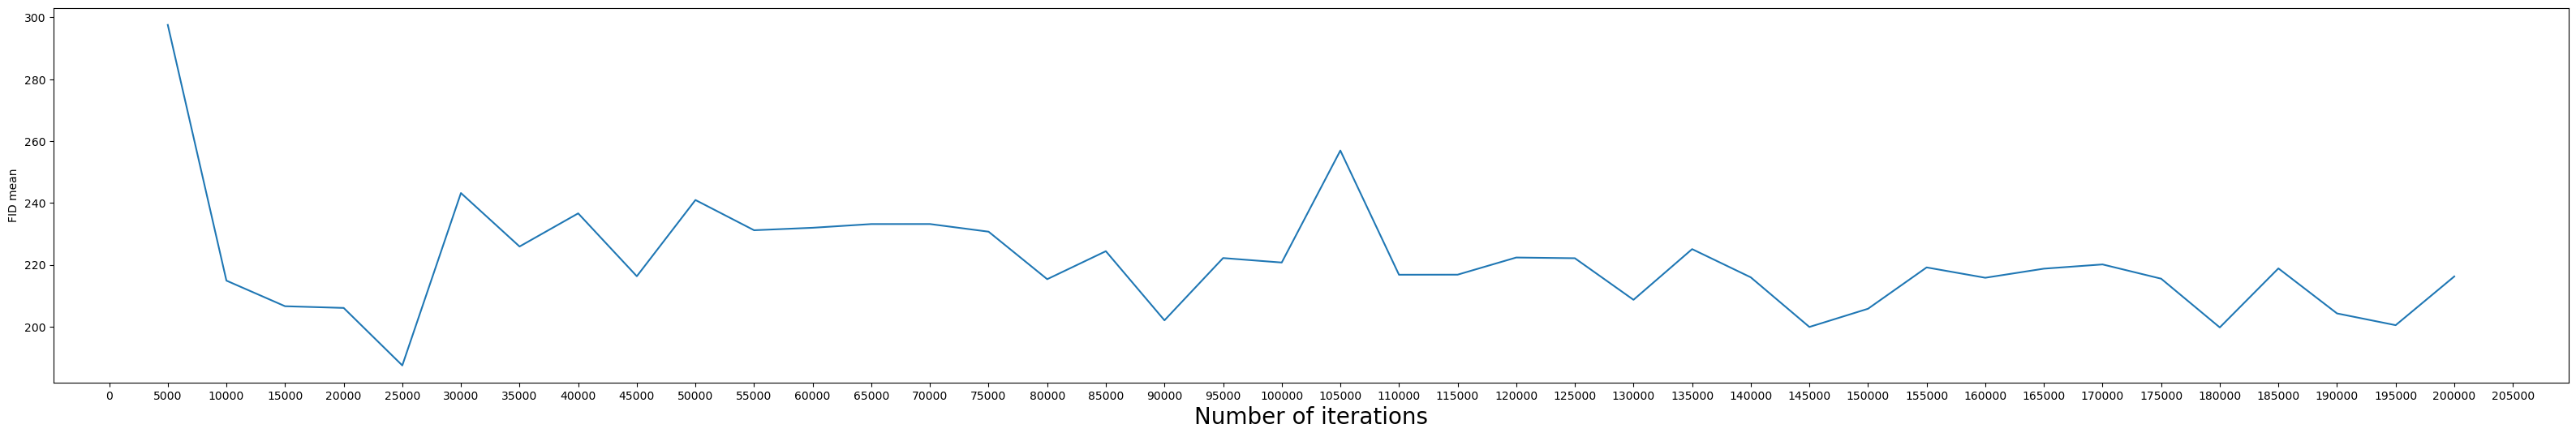

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40,6))
plt.xlabel('Number of iterations', fontsize=20)
plt.ylabel('FID mean')
plt.locator_params(axis='x', nbins=80)
plt.plot(dosgan['iter'], dosgan['fid_mean'])
plt.savefig("dosgan_fid_mean.png", dpi=150)
plt.show()

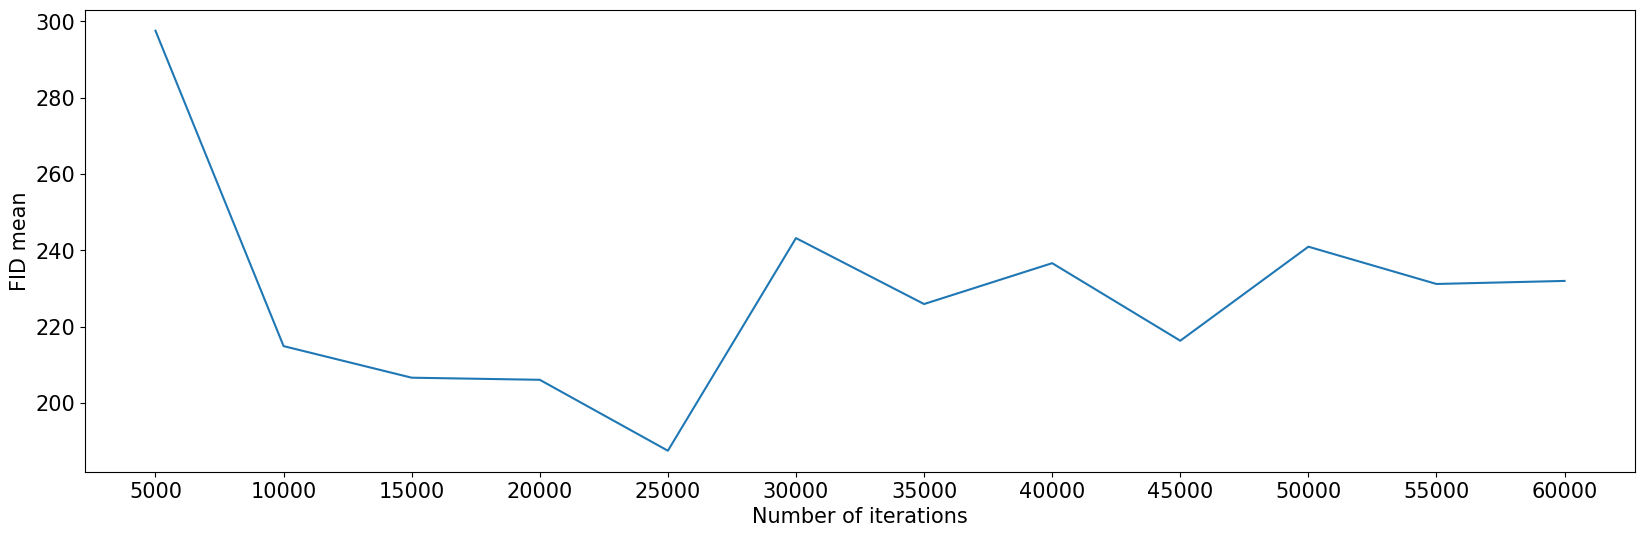

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,6))
plt.xlabel('Number of iterations', fontsize=15)
plt.ylabel('FID mean', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.locator_params(axis='x', nbins=20)
plt.plot(dosgan['iter'].iloc[:12], dosgan['fid_mean'].iloc[:12])
plt.savefig("dosgan_fid_mean.png", dpi=150)
plt.show()

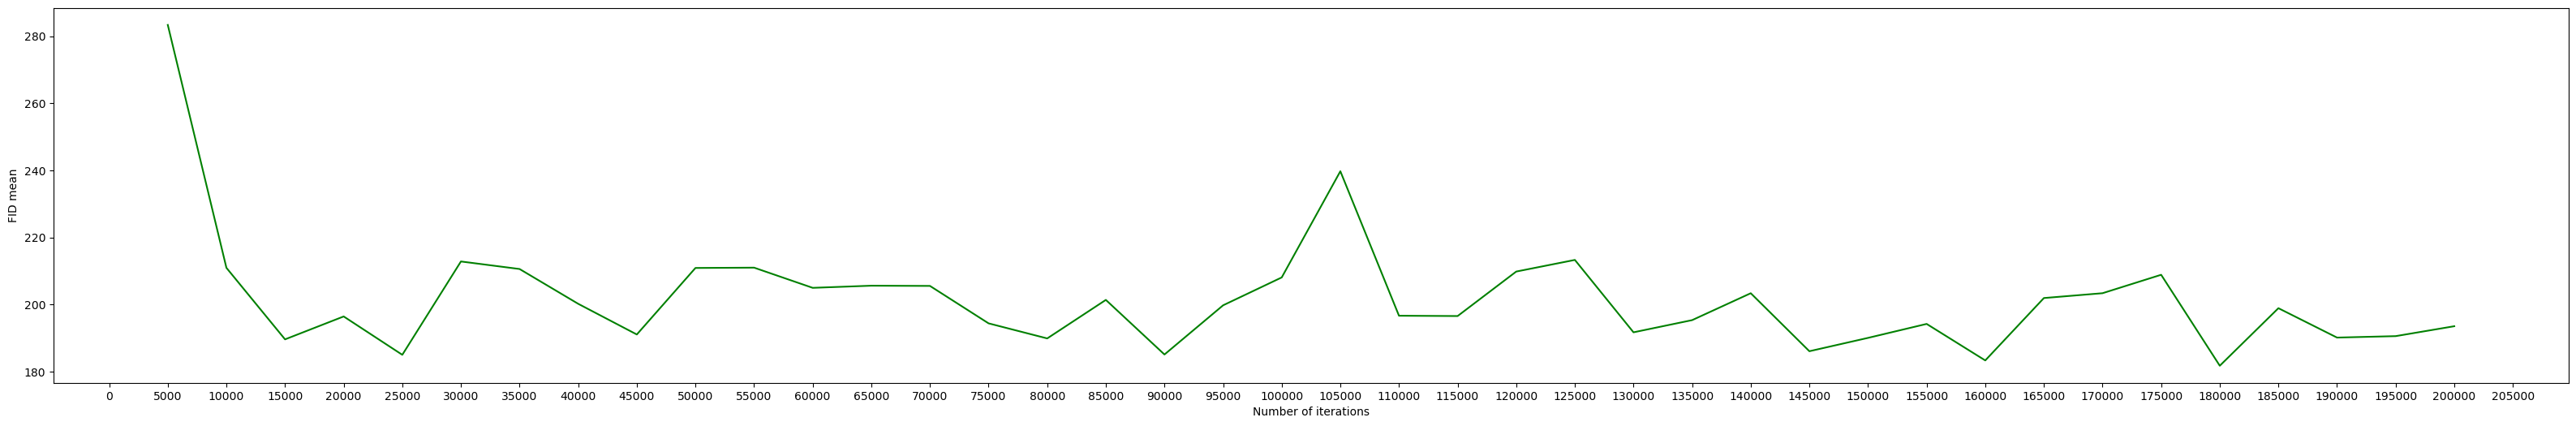

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40,6))
plt.xlabel('Number of iterations')
plt.ylabel('FID mean')
plt.locator_params(axis='x', nbins=80)
plt.plot(dosgan['iter'], dosgan['fid_mean2'])
plt.show()

plt.savefig("dosgan_fid_mean.png", dpi=150)

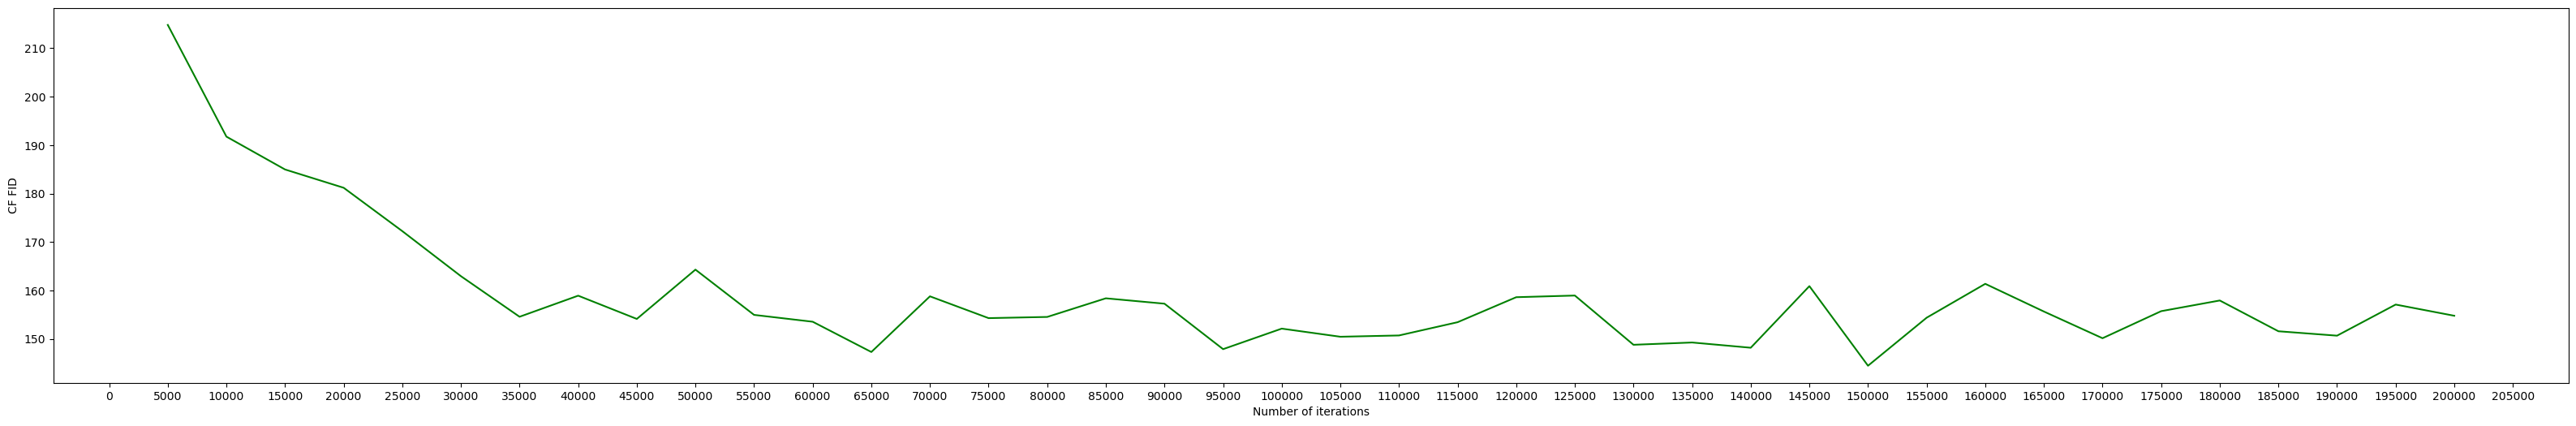

<Figure size 640x480 with 0 Axes>

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40,6))
plt.xlabel('Number of iterations')
plt.ylabel('CF FID')
plt.locator_params(axis='x', nbins=80)
plt.plot(dosgan['iter'], dosgan['cf_fid'], color='green')
plt.show()

plt.savefig("dosgan_fid_cf.png", dpi=150)

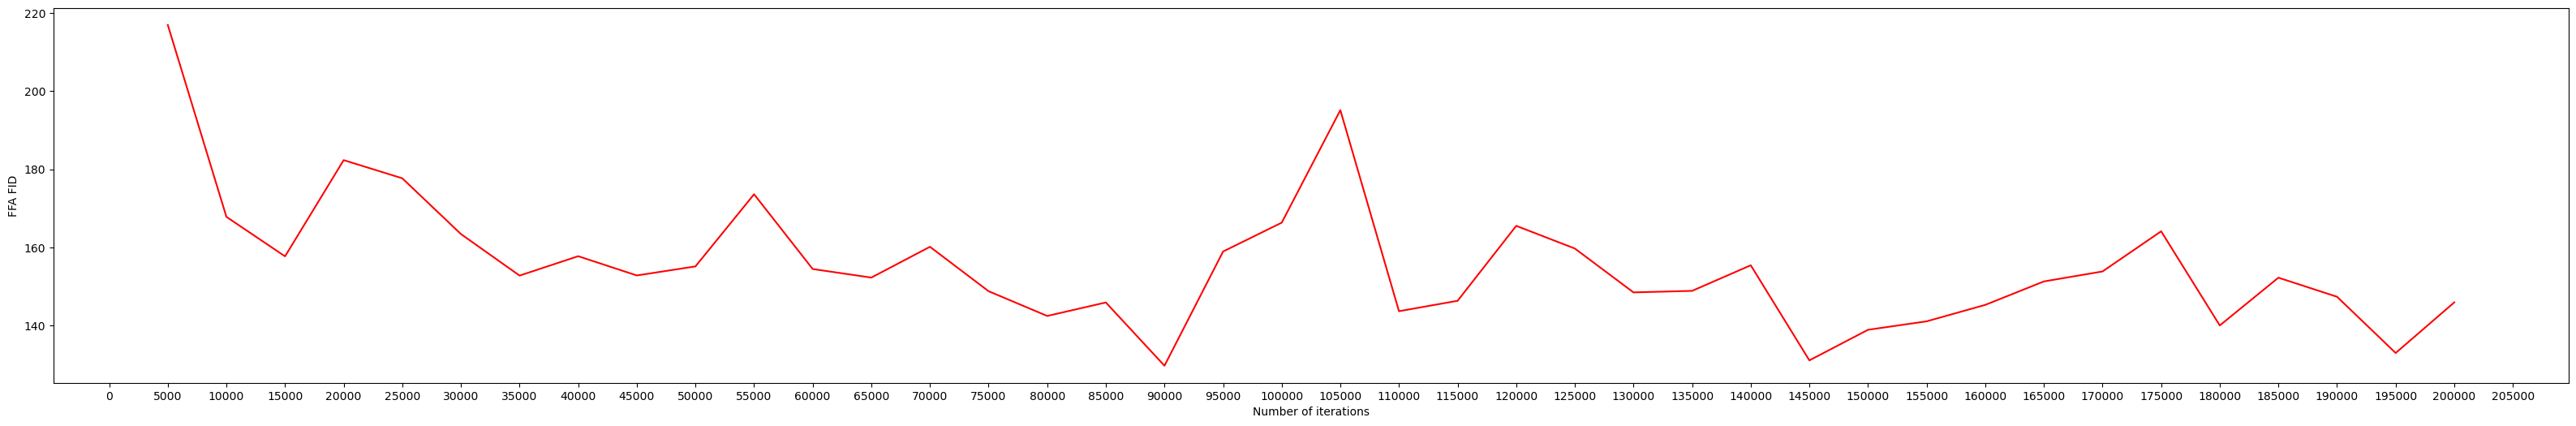

<Figure size 640x480 with 0 Axes>

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40,6))
plt.xlabel('Number of iterations')
plt.ylabel('FFA FID')
plt.locator_params(axis='x', nbins=80)
plt.plot(dosgan['iter'], dosgan['ffa_fid'], color='red')
plt.show()

plt.savefig("dosgan_fid_ffa.png", dpi=150)

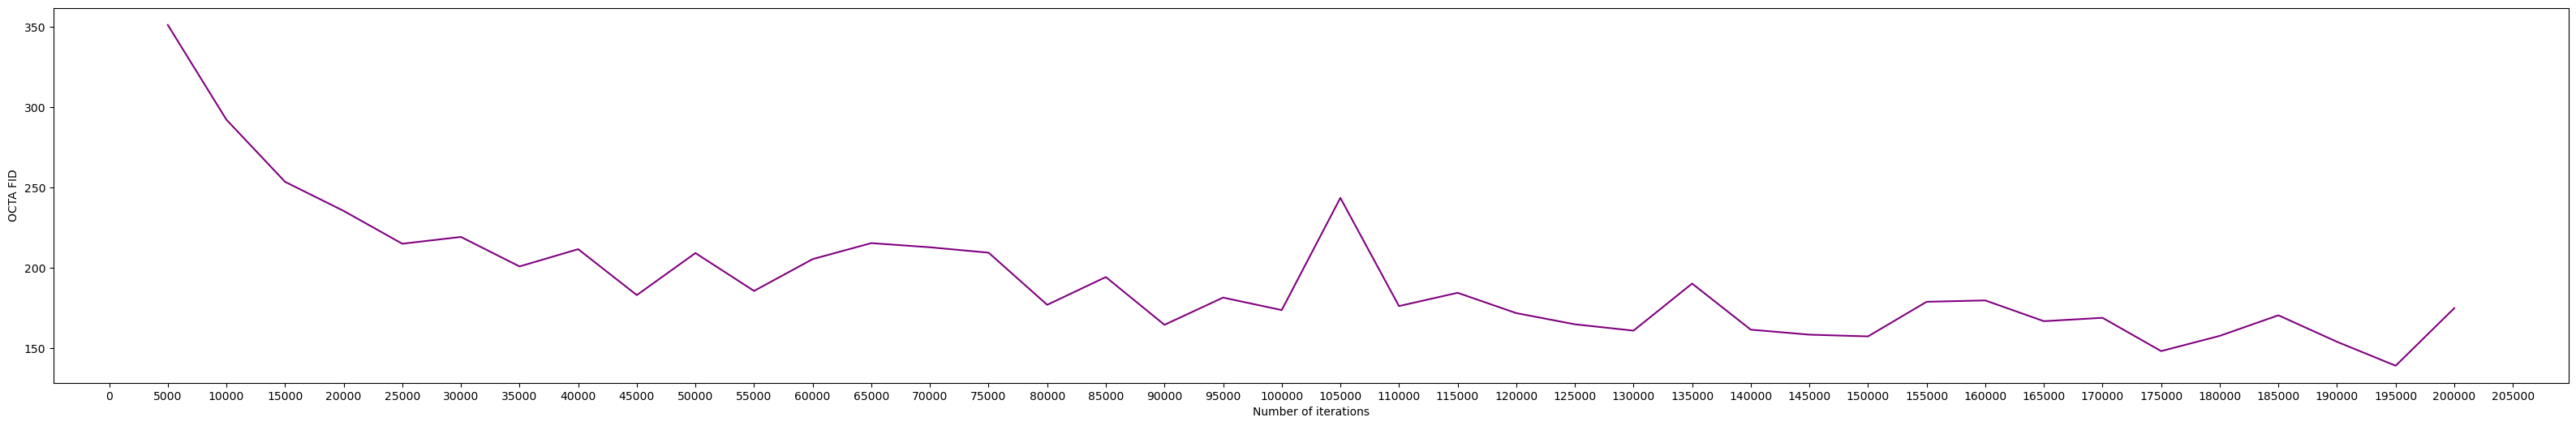

<Figure size 640x480 with 0 Axes>

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(40,6))
plt.xlabel('Number of iterations')
plt.ylabel('OCTA FID')
plt.locator_params(axis='x', nbins=80)
plt.plot(dosgan['iter'], dosgan['octa_fid'], color='purple')
plt.show()

plt.savefig("dosgan_fid_octa.png", dpi=150)

In [74]:
import random
import shutil
import os
from pathlib import Path

dest = 'OCTA/stargan-v2/src'
cf = 'OCTA/256UWOCTA'
ffa = 'OCTA/256FFA'
octa = 'OCTA/256CF'

random.seed(42)

cf_src = random.choice(os.listdir(cf))
# print(os.path.join(cf, cf_src))
shutil.copy(os.path.join(cf, cf_src), dest)

ffa_src = random.choice(os.listdir(ffa))
shutil.copy(os.path.join(ffa, ffa_src), dest)

octa_src = random.choice(os.listdir(octa))
shutil.copy(os.path.join(octa, octa_src), dest)

'OCTA/stargan-v2/src/690.png'

In [7]:
import random
import shutil
import os
from pathlib import Path

octa_r = 'OCTA/stargan-v2/ref/0'
ffa_r = 'OCTA/stargan-v2/ref/1'
cf_r = 'OCTA/stargan-v2/ref/2'
cf = 'OCTA/256UWOCTA'
ffa = 'OCTA/256FFA'
octa = 'OCTA/256CF'

random.seed(42)

for i in range(4):
    cf_ref = random.choice(os.listdir(cf))
    # print(os.path.join(cf, cf_src))
    shutil.copy(os.path.join(cf, cf_ref), octa_r)
    
    ffa_ref = random.choice(os.listdir(ffa))
    shutil.copy(os.path.join(ffa, ffa_ref), ffa_r)
    
    octa_ref = random.choice(os.listdir(octa))
    shutil.copy(os.path.join(octa, octa_ref), cf_r)

In [6]:
import os
import re

folder_path = "/scratch-shared/TSAJOTO001/cf2ffa"

pattern = r"Avg:\s*([\d.]+)"

for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path, filename)
        
        with open(file_path, "r") as f:
            for line in f:
                if "Avg:" in line:
                    match = re.search(pattern, line)
                    if match:
                        value = match.group(1)
                        print(f"{filename}: {value}")

cf2ffa_10000.txt: 0.380955
cf2ffa_100000.txt: 0.380955
cf2ffa_105000.txt: 0.380955
cf2ffa_110000.txt: 0.380955
cf2ffa_115000.txt: 0.380955
cf2ffa_120000.txt: 0.380955
cf2ffa_125000.txt: 0.380955
cf2ffa_130000.txt: 0.380955
cf2ffa_135000.txt: 0.380955
cf2ffa_140000.txt: 0.380955
cf2ffa_145000.txt: 0.380955
cf2ffa_15000.txt: 0.380955
cf2ffa_150000.txt: 0.380955
cf2ffa_155000.txt: 0.380955
cf2ffa_160000.txt: 0.380955
cf2ffa_165000.txt: 0.380955
cf2ffa_170000.txt: 0.380955
cf2ffa_175000.txt: 0.380955
cf2ffa_180000.txt: 0.380955
cf2ffa_185000.txt: 0.380955
cf2ffa_190000.txt: 0.380955
cf2ffa_195000.txt: 0.380955
cf2ffa_20000.txt: 0.380955
cf2ffa_200000.txt: 0.380955
cf2ffa_25000.txt: 0.380955
cf2ffa_30000.txt: 0.380955
cf2ffa_35000.txt: 0.380955
cf2ffa_40000.txt: 0.380955
cf2ffa_45000.txt: 0.380955
cf2ffa_5000.txt: 0.380955
cf2ffa_50000.txt: 0.380955
cf2ffa_55000.txt: 0.380955
cf2ffa_60000.txt: 0.380955
cf2ffa_65000.txt: 0.380955
cf2ffa_70000.txt: 0.380955
cf2ffa_75000.txt: 0.380955
cf2ffa_8